# MIDTERM PROJECT_ BY ABDULSAMAD NURADEEN

**Predicting Housing Prices in Buenos Aires Project!**

Importing files

In [ ]:
import numpy as np
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
import seaborn as sns
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.preprocessing import OneHotEncoder
from IPython.display import VimeoVideo
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.utils.validation import check_is_fitted
import plotly.express as px
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline, make_pipeline

In [ ]:
def wrangle(filepath):
  df = pd.read_csv(filepath)

  # Subset property in `"Capital Federal"`
  mask_ba = df['place_with_parent_names'].str.contains('Capital Federal')

  # Subset to apartment
  mask_apt = df['property_type'] == 'apartment'

  # Subset property where `"price appro usd"` < 400,000
  mask_price = df['price_aprox_usd'] < 400_000

  df = df[mask_ba & mask_apt & mask_price]

  # Remove outliers
  low, high = df['surface_covered_in_m2'].quantile([0.1, 0.9])
  mask_area = df['surface_covered_in_m2'].between(low, high)
  df = df[mask_area]

  # Split "lat-lon" columns
  df[['lat', 'lon']] = df['lat-lon'].str.split(",", expand=True).astype(float)
  df.drop(columns=['lat-lon'], inplace=True)

  # Extract neighborhood
  df['neighborhood'] = df["place_with_parent_names"].str.split("|", expand=True)[3]
  df.drop(columns='place_with_parent_names', inplace=True)

  # drop feature with high null value
  df.drop(columns=['floor', 'expenses'], inplace=True)

  # drop low and high cardinaly columns
  df.drop(columns=['operation', 'property_type', 'properati_url', 'currency'], inplace=True)

  # drop leaky columns
  df.drop(
        columns=[
            'price',
            'price_aprox_local_currency',
            'price_per_m2',
            'price_usd_per_m2'
        ], inplace=True
    )

  # Drop multiple linear colinearity
  df.drop(columns=["surface_total_in_m2", "rooms"], inplace=True)

  return df

In [ ]:
frame1 = wrangle('/content/buenos-aires-real-estate-1.csv')
print('df shapes: ', frame1.shape)
frame1.head()

df shapes:  (1343, 5)


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
4,129000.0,70.0,-34.584651,-58.454693,Chacarita
9,87000.0,42.0,-34.638979,-58.500115,Villa Luro
29,118000.0,54.0,-34.615847,-58.459957,Caballito
40,57000.0,42.0,-34.625222,-58.382382,Constitución
41,90000.0,50.0,-34.610610,-58.412511,Once


In [ ]:
frame2 = wrangle('/content/buenos-aires-real-estate-2.csv')

In [ ]:
files = glob('/content/buenos-aires-real-estate-*.csv')
files

['/content/buenos-aires-real-estate-1.csv',
 '/content/buenos-aires-real-estate-4.csv',
 '/content/buenos-aires-real-estate-5.csv',
 '/content/buenos-aires-real-estate-3.csv',
 '/content/buenos-aires-real-estate-2.csv']

In [ ]:
frames = []
for file in files:
  df = wrangle(file)
  frames.append(df)

In [ ]:
df = pd.concat(frames, ignore_index=True)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6582 entries, 0 to 6581
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6582 non-null   float64
 1   surface_covered_in_m2  6582 non-null   float64
 2   lat                    6316 non-null   float64
 3   lon                    6316 non-null   float64
 4   neighborhood           6582 non-null   object 
dtypes: float64(4), object(1)
memory usage: 257.2+ KB
None


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
0,129000.0,70.0,-34.584651,-58.454693,Chacarita
1,87000.0,42.0,-34.638979,-58.500115,Villa Luro
2,118000.0,54.0,-34.615847,-58.459957,Caballito
3,57000.0,42.0,-34.625222,-58.382382,Constitución
4,90000.0,50.0,-34.610610,-58.412511,Once


# Exploratory Data Analysis(EDA)

**Distribution of Apartment Sizes**

Text(0.5, 1.0, 'Distribution of Apartment Sizes')

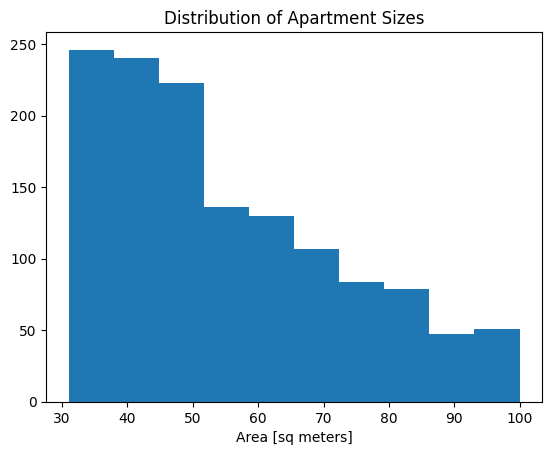

In [ ]:
plt.hist(frame1["surface_covered_in_m2"])
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Apartment Sizes")

In [ ]:
frame1.describe()['surface_covered_in_m2']

,surface_covered_in_m2
count,1343.000000
mean,55.076694
std,18.160427
min,31.000000
25%,40.000000
50%,50.000000
75%,68.500000
max,100.000000


# The relationship between Area and Price

Text(0.5, 1.0, 'Buenos Aires: Area vs Price ')

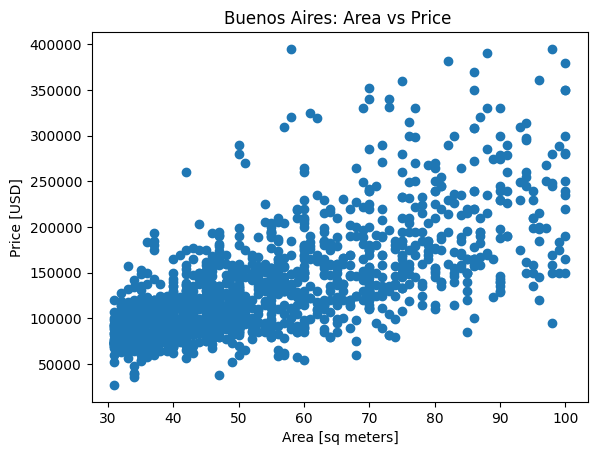

In [ ]:
plt.scatter(x=frame1['surface_covered_in_m2'], y=frame1['price_aprox_usd'])
plt.xlabel('Area [sq meters]')
plt.ylabel('Price [USD]')
plt.title('Buenos Aires: Area vs Price ')

In [ ]:
fig = px.scatter_mapbox(
    df,  # Our DataFrame
    lat= "lat",
    lon= "lon",
    width=600,  # Width of map
    height=600,  # Height of map
    color= "price_aprox_usd",
    hover_data=["price_aprox_usd"],  # Display price when hovering mouse over house
)

fig.update_layout(mapbox_style="open-street-map")

fig.show()

In [ ]:
# Create 3D scatter plot
fig = px.scatter_3d(
    df,
    x= "lat",
    y= "lon",
    z= "price_aprox_usd",
    labels={"lon": "longitude", "lat": "latitude", "price_aprox_usd": "price"},
    width=600,
    height=500,
)

# Refine formatting
fig.update_traces(
    marker={"size": 4, "line": {"width": 2, "color": "DarkSlateGrey"}},
    selector={"mode": "markers"},
)

# Display figure
fig.show()

<Axes: >

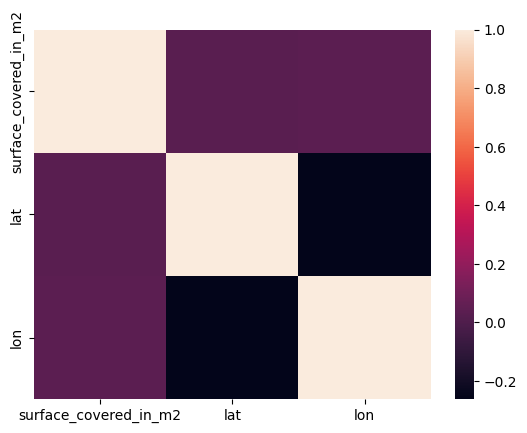

In [ ]:
corr = df.select_dtypes("number").drop(columns="price_aprox_usd").corr()
sns.heatmap(corr)

# Splitting the dataset

In [ ]:
features = ["surface_covered_in_m2"]
X_train = frame1[features]
X_train.head()

,surface_covered_in_m2
4,70.0
9,42.0
29,54.0
40,42.0
41,50.0


In [ ]:
target = "price_aprox_usd"
y_train = frame1[target]
y_train.head()

,price_aprox_usd
4,129000.0
9,87000.0
29,118000.0
40,57000.0
41,90000.0


In [ ]:
features_2 = ["lon", "lat"]
X_train_2 = df[features_2]
X_train_2.head()

,lon,lat
0,-58.454693,-34.584651
1,-58.500115,-34.638979
2,-58.459957,-34.615847
3,-58.382382,-34.625222
4,-58.412511,-34.610610


In [ ]:
target = "price_aprox_usd"
y_train_2 = df[target]
y_train_2.head()

,price_aprox_usd
0,129000.0
1,87000.0
2,118000.0
3,57000.0
4,90000.0


In [ ]:
target_3 = "price_aprox_usd"
features_3 = ["neighborhood"]
y_train_3 = df[target_3]
X_train_3 = df[features_3]

In [ ]:
target_4 = "price_aprox_usd"
y_train_4 = df[target_4]
X_train_4 = df.drop(columns=target)
X_train_4.head()

,surface_covered_in_m2,lat,lon,neighborhood
0,70.0,-34.584651,-58.454693,Chacarita
1,42.0,-34.638979,-58.500115,Villa Luro
2,54.0,-34.615847,-58.459957,Caballito
3,42.0,-34.625222,-58.382382,Constitución
4,50.0,-34.610610,-58.412511,Once


# Build Model

**Baseline**

In [ ]:
y_mean = y_train.mean()
y_mean

np.float64(135527.83871928515)

In [ ]:
y_pred_baseline = [y_mean] * len(y_train)
y_pred_baseline[:2]

[np.float64(135527.83871928515), np.float64(135527.83871928515)]

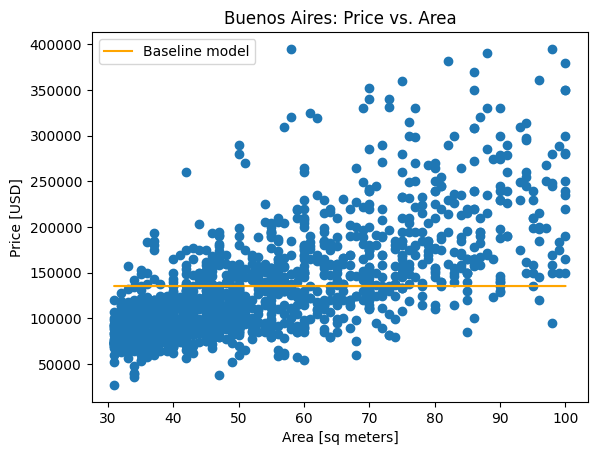

In [ ]:
# Add a line to the plot
plt.plot(X_train.values, y_pred_baseline, color='orange', label="Baseline model")

plt.scatter(X_train, y_train)
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos Aires: Price vs. Area")
plt.legend();

In [ ]:
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean apt price", round(y_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean apt price 135527.84
Baseline MAE: 45199.46


**Baseline_2**

In [ ]:
y_mean_2 = y_train_2.mean()
y_mean_2

np.float64(134732.97340481562)

In [ ]:
y_pred_baseline_2 = [y_mean_2] * len(y_train)
y_pred_baseline_2[:2]

[np.float64(134732.97340481562), np.float64(134732.97340481562)]

In [ ]:
mae_baseline = mean_absolute_error(y_train_2, y_pred_baseline_2)

print("Mean apt price", round(y_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean apt price 135527.84
Baseline MAE: 45422.75


## Iterate

**Baseline_3**

In [ ]:
y_mean = y_train_3.mean()
y_pred_baseline = [y_mean] * len(y_train_3)

print("Mean apt price:", y_mean)

print("Baseline MAE:", mean_absolute_error(y_train, y_pred_baseline))

Mean apt price: 132383.83701458524
Baseline MAE: 44860.10834274133


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Baseline_4**

In [ ]:
y_mean_4 = y_train_4.mean()
y_pred_baseline_4 = [y_mean_4] * len(y_train)
y_pred_baseline_4[:2]
print("Mean apt price:", y_mean.round(2))
print("Baseline MAE:", mean_absolute_error(y_train, y_pred_baseline))

Mean apt price: 132383.84
Baseline MAE: 44860.10834274133


In [ ]:
model_4 = make_pipeline(
    OneHotEncoder(handle_unknown='ignore'),
    SimpleImputer(),
    Ridge()
)
model_4.fit(X_train_4, y_train_4)

Pipeline(steps=[('onehotencoder', OneHotEncoder(handle_unknown='ignore')),
                ('simpleimputer', SimpleImputer()), ('ridge', Ridge())])

In [ ]:
y_train_4.head()

,price_aprox_usd
0,129000.0
1,87000.0
2,118000.0
3,57000.0
4,90000.0


In [ ]:
y_pred_baseline_4 = model_4.predict(X_train_4)
print("Training MAE:", mean_absolute_error(y_train_4, y_pred_baseline_4))

Training MAE: 9572.676485757343


**Train model**

In [ ]:
y_pred_training = model.predict(X_train)
y_pred_training[:5]

array([169151.87330223, 106064.44707446, 133101.91545779, 106064.44707446,
       124089.42599668])

**model evaluation**

In [ ]:
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE:", round(mae_training, 2))

Training MAE: 31248.26


Good news: Our model beat the baseline by over \$10,000! That's a good indicator that it will be helpful in predicting apartment prices. But the real test is how the model performs on data that it hasn't seen before, data that we call the **test set**. In the future, you'll create your own test set before you train your model, but here we'll use one that's pre-made, and we'll evaluate the model using the WQU auto-grader.

**testing a model**

In [ ]:
X_test = pd.read_csv("/content/buenos-aires-test-features.csv")[features]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

,0
0,117330.058901
1,135355.037823
2,88039.468152
3,88039.468152
4,106064.447074


## Iterate_2

In [ ]:
imputer = SimpleImputer()
imputer.fit(X_train)

SimpleImputer()

In [ ]:
XT_train = imputer.transform(X_train)
pd.DataFrame(XT_train, columns=X_train.columns).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658 entries, 0 to 2657
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   lon     2658 non-null   float64
 1   lat     2658 non-null   float64
dtypes: float64(2)
memory usage: 41.7 KB


## Iterate_3

In [ ]:
ohe = OneHotEncoder()
ohe.fit(X_train_3)
XT_train = ohe.transform(X_train_3)
print(XT_train.shape)
XT_train

(6582, 57)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6582 stored elements and shape (6582, 57)>

**Building model**

In [ ]:
model_2 = make_pipeline(
    SimpleImputer(),
    LinearRegression()
)

In [ ]:
model_3 = make_pipeline(
    OneHotEncoder(handle_unknown='ignore'),
    Ridge()
)
model_3.fit(X_train_3, y_train_3)

Pipeline(steps=[('onehotencoder', OneHotEncoder(handle_unknown='ignore')),
                ('ridge', Ridge())])

**Train model**

In [ ]:
model_2.fit(X_train_2, y_train_2)

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('linearregression', LinearRegression())])

**Generate prediction**

In [ ]:
y_pred_training_2 = model_2.predict(X_train_2)
y_pred_training_2[:5]

array([141604.16877107,  91083.01606221, 116689.16908219, 124772.63112889,
       130030.89843681])

In [ ]:
mae_training = mean_absolute_error(y_train_2, y_pred_training_2)
print("Training MAE:", round(mae_training, 2))

Training MAE: 42962.72


In [ ]:
y_pred_training_3 = model_3.predict(X_train_3)
mae_training = mean_absolute_error(y_train_3, y_pred_training_3)
print("Training MAE:", round(mae_training, 2))

Training MAE: 39350.2


**Test model**

In [ ]:
X_test = pd.read_csv("/content/buenos-aires-test-features.csv")[features_2]
y_pred_test = pd.Series(model_2.predict(X_test))
y_pred_test.head()

,0
0,136372.324695
1,168620.352353
2,130231.628267
3,102497.549527
4,123482.077850


In [ ]:
X_test = pd.read_csv("/content/buenos-aires-test-features.csv")[features_3]
y_pred_test = pd.Series(model_3.predict(X_test))
y_pred_test.head()

,0
0,246626.766351
1,161356.120313
2,98233.734929
3,110848.625817
4,127777.643897


**Test model_4**

In [ ]:
X_test = pd.read_csv("/content/buenos-aires-test-features.csv")
y_pred_test = pd.Series(model_4.predict(X_test))
y_pred_test.head()

,0
0,186676.077999
1,158368.262457
2,79484.117878
3,49780.771021
4,99825.205156


# Communicate Results

**model intercept**

In [ ]:
intercept = round(model.intercept_, 2)
print("Model Intercept:", intercept)
assert any([isinstance(intercept, int), isinstance(intercept, float)])

Model Intercept: 11433.31


**model coefficient**

In [ ]:
coefficient = round(model.coef_[0], 2)
print('Model coefficient for "surface_covered_in_m2":', coefficient)
assert any([isinstance(coefficient, int), isinstance(coefficient, float)])

Model coefficient for "surface_covered_in_m2": 2253.12


**Generate Equation**

In [ ]:
print(f"apartment_price = {intercept} + {coefficient} * surface_covered")

apartment_price = 11433.31 + 2253.12 * surface_covered


**Displaying Equation**

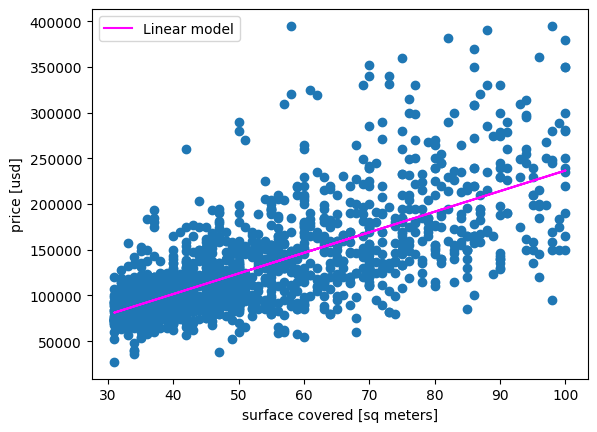

In [ ]:
# Add a line to the plot
plt.plot(X_train, model.predict(X_train), color='magenta', label='Linear model')

plt.scatter(X_train, y_train)
plt.xlabel("surface covered [sq meters]")
plt.ylabel("price [usd]")
plt.legend();

**Communicate result_2**

In [ ]:
intercept = model.named_steps['linearregression'].intercept_.round(2)
coefficients = model.named_steps['linearregression'].coef_.round(2)
coefficients

array([196709.42, 765466.58])

In [ ]:
print(
    f"price = {intercept} + ({coefficients[0]} * longitude) + ({coefficients[1]} * latitude)")

price = 38113587.05 + (196709.42 * longitude) + (765466.58 * latitude)


In [ ]:
# Create 3D scatter plot
fig = px.scatter_3d(
    df,
    x= "lon",
    y= "lat",
    z= "price_aprox_usd",
    labels={"lon": "longitude", "lat": "latitude", "price_aprox_usd": "price"},
    width=600,
    height=500,
)

# Create x and y coordinates for model representation
x_plane = np.linspace(df["lon"].min(), df["lon"].max(), 10)
y_plane = np.linspace(df["lat"].min(), df["lat"].max(), 10)
xx, yy = np.meshgrid(x_plane, y_plane)

# Use model to predict z coordinates
z_plane = model_2.predict(pd.DataFrame({"lon": x_plane, "lat": y_plane}))
zz = np.tile(z_plane, (10, 1))

# Add plane to figure
fig.add_trace(go.Surface(x=xx, y=yy, z=zz))

# Refine formatting
fig.update_traces(
    marker={"size": 4, "line": {"width": 2, "color": "DarkSlateGrey"}},
    selector={"mode": "markers"},
)

# Display figure
fig.show()

In [ ]:
intercept = model_3.named_steps['ridge'].intercept_
coefficients = model_3.named_steps['ridge'].coef_
print("coefficients len:", len(coefficients))
print(coefficients[:5])  # First five coefficients

coefficients len: 57
[-19371.22172305   4332.95272632   -780.49618777   2904.72539756
 -11171.00781758]


In [ ]:
feature_names = model_3.named_steps['onehotencoder'].get_feature_names_out()
print("features len:", len(feature_names))
print(feature_names[:5])  # First five feature names

features len: 57
['neighborhood_' 'neighborhood_Abasto' 'neighborhood_Agronomía'
 'neighborhood_Almagro' 'neighborhood_Balvanera']


In [ ]:
feat_imp = pd.Series(coefficients, feature_names)
feat_imp.head()

,0
neighborhood_,-19371.221723
neighborhood_Abasto,4332.952726
neighborhood_Agronomía,-780.496188
neighborhood_Almagro,2904.725398
neighborhood_Balvanera,-11171.007818


In [ ]:
print(f"price = {intercept.round(2)}")
for f, c in feat_imp.items():
    print(f"+ ({round(c, 2)} * {f})")

price = 118523.28
+ (-19371.22 * neighborhood_)
+ (4332.95 * neighborhood_Abasto)
+ (-780.5 * neighborhood_Agronomía)
+ (2904.73 * neighborhood_Almagro)
+ (-11171.01 * neighborhood_Balvanera)
+ (-4616.71 * neighborhood_Barracas)
+ (55592.53 * neighborhood_Barrio Norte)
+ (46955.66 * neighborhood_Belgrano)
+ (-28351.3 * neighborhood_Boca)
+ (-6833.0 * neighborhood_Boedo)
+ (9254.36 * neighborhood_Caballito)
+ (-22004.26 * neighborhood_Catalinas)
+ (-7902.04 * neighborhood_Centro / Microcentro)
+ (-2895.47 * neighborhood_Chacarita)
+ (12220.46 * neighborhood_Coghlan)
+ (38438.18 * neighborhood_Colegiales)
+ (-7971.12 * neighborhood_Congreso)
+ (-41741.39 * neighborhood_Constitución)
+ (-8660.83 * neighborhood_Flores)
+ (-14085.93 * neighborhood_Floresta)
+ (72262.09 * neighborhood_Las Cañitas)
+ (-13726.25 * neighborhood_Liniers)
+ (-21078.6 * neighborhood_Mataderos)
+ (-20289.55 * neighborhood_Monserrat)
+ (-3424.33 * neighborhood_Monte Castro)
+ (42832.84 * neighborhood_Nuñez)
+ (-3227

In [ ]:
def make_prediction(area, lat, lon, neighborhood):
    data = {
        "surface_covered_in_m2": area,
        "lat": lat,
        "lon": lon,
        "neighborhood": neighborhood
    }
    df = pd.DataFrame(data=data, index=[0])
    prediction = model_4.predict(df).round(2)[0]
    return f"Predicted apartment price: ${prediction}"

In [ ]:
make_prediction(110, -34.60, -58.46, "Villa Crespo")

'Predicted apartment price: $127912.71'

In [ ]:
interact(
    make_prediction,
    area=IntSlider(
        min=X_train_4["surface_covered_in_m2"].min(),
        max=X_train_4["surface_covered_in_m2"].max(),
        value=X_train_4["surface_covered_in_m2"].mean(),
    ),
    lat=FloatSlider(
        min=X_train_4["lat"].min(),
        max=X_train_4["lat"].max(),
        step=0.01,
        value=X_train_4["lat"].mean(),
    ),
    lon=FloatSlider(
        min=X_train_4["lon"].min(),
        max=X_train_4["lon"].max(),
        step=0.01,
        value=X_train_4["lon"].mean(),
    ),
    neighborhood=Dropdown(options=sorted(X_train_4["neighborhood"].unique())),
);

interactive(children=(IntSlider(value=53, description='area', max=101, min=30), FloatSlider(value=-34.59890626…